<a href="https://www.kaggle.com/code/lalit7881/desi-dark-energy-stellar-classification-eda?scriptVersionId=311128672" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/desi-dark-energy-stellar-classification/desi_dr1_ultimate.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/desi-dark-energy-stellar-classification/desi_dr1_ultimate.csv")

In [3]:
df.head()

,targetid,healpix,ra,dec,redshift,redshift_err,spectype,subtype,deltachi2,chi2,...,snr_r,snr_z,luminosity_distance_mpc,comoving_distance_mpc,lookback_time_gyr,abs_mag_r,redshift_confidence,morphtype_label,galaxy_color_class,deep_obs_flag
0,39628365690307709,741,33.037640,24.844902,1.747032,0.001586,QSO,HIZ,28.401550,7534.991513,...,7.729358,9.117406,13163.869822,4792.033371,9.799481,-22.286156,Moderate,Round Exponential,NaN,0
1,2714944399212545,17996,16.571421,-1.504480,0.209861,0.000009,GALAXY,NaN,572.310340,7875.553116,...,137.393962,73.856041,1034.289646,854.883064,2.535272,-19.524550,High,Exponential Disk (late-type),Blue Cloud,0
2,2349936800694272,18006,20.330022,-0.340878,0.766918,0.000142,GALAXY,NaN,197.099793,7808.884794,...,106.028605,79.282391,4764.048821,2696.247689,6.660354,-22.827631,High,Sersic Profile,Red Sequence,0
3,2715032676728834,31429,238.474281,2.067749,0.199573,0.000006,GALAXY,NaN,1317.058164,7679.890371,...,80.824023,49.891636,977.733498,815.067700,2.427478,-19.148888,Very High,Exponential Disk (late-type),Red Sequence,0
4,2305843019036772569,9369,243.782457,29.614561,-0.000806,0.000009,STAR,K,1172.646961,7677.044633,...,605.532808,462.925362,NaN,NaN,NaN,NaN,Very High,Point Source (unresolved),NaN,0


In [4]:
df.tail()

,targetid,healpix,ra,dec,redshift,redshift_err,spectype,subtype,deltachi2,chi2,...,snr_r,snr_z,luminosity_distance_mpc,comoving_distance_mpc,lookback_time_gyr,abs_mag_r,redshift_confidence,morphtype_label,galaxy_color_class,deep_obs_flag
49995,2715007972278272,26029,205.797881,0.897988,0.144694,0.000021,GALAXY,NaN,89.061175,8066.143452,...,53.067259,36.448548,685.658603,598.988498,1.826042,-18.425998,Moderate,Exponential Disk (late-type),Blue Cloud,0
49996,39633312263700507,15273,273.412900,54.157949,-0.000397,0.000001,STAR,G,72441.936701,13508.814107,...,906.237643,1237.001590,NaN,NaN,NaN,NaN,Very High,Point Source (unresolved),NaN,0
49997,39627557271767823,22635,68.955280,-9.531397,0.000013,0.000008,STAR,M,2843.937306,9173.452982,...,14.445188,40.863001,NaN,NaN,NaN,NaN,Very High,Point Source (unresolved),NaN,0
49998,2390006589030403,4785,118.971519,20.247618,0.029373,0.000010,GALAXY,NaN,157.318413,7723.300417,...,41.816256,6.918292,128.633280,124.962692,0.401716,-14.325446,High,Sersic Profile,Blue Cloud,0
49999,2715068852600835,31438,235.539259,3.500550,0.115115,0.000017,GALAXY,NaN,202.418956,7672.209589,...,60.741686,33.269182,535.215161,479.964072,1.482437,-17.745611,High,Round Exponential,Blue Cloud,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   targetid                 50000 non-null  int64  
 1   healpix                  50000 non-null  int64  
 2   ra                       50000 non-null  float64
 3   dec                      50000 non-null  float64
 4   redshift                 50000 non-null  float64
 5   redshift_err             50000 non-null  float64
 6   spectype                 50000 non-null  object 
 7   subtype                  30000 non-null  object 
 8   deltachi2                50000 non-null  float64
 9   chi2                     50000 non-null  float64
 10  npixels                  50000 non-null  int64  
 11  coadd_numexp             50000 non-null  int64  
 12  coadd_exptime            50000 non-null  float64
 13  tsnr2_elg                50000 non-null  float64
 14  tsnr2_lrg             

In [6]:
df.describe()

,targetid,healpix,ra,dec,redshift,redshift_err,deltachi2,chi2,npixels,coadd_numexp,...,color_w1_w2,agn_wise_flag,snr_g,snr_r,snr_z,luminosity_distance_mpc,comoving_distance_mpc,lookback_time_gyr,abs_mag_r,deep_obs_flag
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,50000.000000,50000.000000,...,45914.000000,50000.000000,49997.000000,49997.000000,49997.000000,35036.000000,35036.000000,35036.000000,35036.000000,50000.000000
mean,1.975935e+17,20972.471460,178.176780,10.835819,0.594610,1.701515e-04,1.685955e+04,1.170735e+04,7861.448080,1.435640,...,-0.310528,0.123860,289.436475,304.623469,282.183846,6238.630542,2382.534371,5.243716,-20.990122,0.031940
std,6.067033e+17,9840.838183,86.654752,18.551627,0.848957,3.599899e-04,8.425578e+04,2.183460e+04,57.314861,0.841304,...,0.813788,0.329425,490.454520,498.825600,468.311489,7521.690577,2071.651104,3.775872,3.060568,0.175842
min,2.253019e+15,0.000000,0.002407,-26.840767,-0.001909,1.907813e-07,2.500864e+01,4.730354e+03,4960.000000,1.000000,...,-11.819466,0.000000,0.156067,0.002114,0.301790,4.296207,4.291905,0.013991,-29.944429,0.000000
25%,2.715017e+15,11150.000000,133.052663,-1.391172,0.000156,4.244810e-06,4.243142e+02,7.901413e+03,7825.000000,1.000000,...,-0.710395,0.000000,53.867418,52.252245,32.676071,790.583715,678.747437,2.051332,-23.668579,0.000000
50%,3.962771e+16,22764.000000,181.552018,3.727409,0.178615,9.794387e-06,1.510031e+03,8.269489e+03,7861.000000,1.000000,...,-0.372071,0.000000,89.527594,85.762172,54.956040,1367.251681,1077.813388,3.122206,-20.060933,0.000000
75%,3.962829e+16,27196.000000,232.110943,18.758882,1.023012,1.389042e-04,5.998484e+03,9.384579e+03,7917.000000,2.000000,...,0.279241,0.000000,296.066459,336.598261,329.762739,11219.046203,4426.734763,9.347728,-18.779220,0.000000
max,2.305843e+18,49151.000000,359.999088,83.625967,5.690984,7.030703e-03,2.999894e+06,2.243323e+06,7931.000000,9.000000,...,6.999464,1.000000,6370.366220,4893.675340,4371.322735,54280.325535,8112.458384,12.485915,-5.424926,1.000000


In [7]:
df.columns

Index(['targetid', 'healpix', 'ra', 'dec', 'redshift', 'redshift_err',
       'spectype', 'subtype', 'deltachi2', 'chi2', 'npixels', 'coadd_numexp',
       'coadd_exptime', 'tsnr2_elg', 'tsnr2_lrg', 'tsnr2_qso', 'tsnr2_bgs',
       'flux_g', 'flux_r', 'flux_z', 'flux_w1', 'flux_w2', 'flux_ivar_g',
       'flux_ivar_r', 'flux_ivar_z', 'morphtype', 'ebv', 'nobs_g', 'nobs_r',
       'nobs_z', 'mag_g', 'mag_r', 'mag_z', 'mag_w1', 'mag_w2', 'color_g_r',
       'color_r_z', 'color_g_z', 'color_w1_w2', 'agn_wise_flag', 'snr_g',
       'snr_r', 'snr_z', 'luminosity_distance_mpc', 'comoving_distance_mpc',
       'lookback_time_gyr', 'abs_mag_r', 'redshift_confidence',
       'morphtype_label', 'galaxy_color_class', 'deep_obs_flag'],
      dtype='object')

In [8]:
df.isnull().sum()

targetid                       0
healpix                        0
ra                             0
dec                            0
redshift                       0
redshift_err                   0
spectype                       0
subtype                    20000
deltachi2                      0
chi2                           0
npixels                        0
coadd_numexp                   0
coadd_exptime                  0
tsnr2_elg                      0
tsnr2_lrg                      0
tsnr2_qso                      0
tsnr2_bgs                      0
flux_g                         0
flux_r                         0
flux_z                         0
flux_w1                        0
flux_w2                        0
flux_ivar_g                    0
flux_ivar_r                    0
flux_ivar_z                    0
morphtype                      0
ebv                            0
nobs_g                         0
nobs_r                         0
nobs_z                         0
mag_g     

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

targetid                     int64
healpix                      int64
ra                         float64
dec                        float64
redshift                   float64
redshift_err               float64
spectype                    object
subtype                     object
deltachi2                  float64
chi2                       float64
npixels                      int64
coadd_numexp                 int64
coadd_exptime              float64
tsnr2_elg                  float64
tsnr2_lrg                  float64
tsnr2_qso                  float64
tsnr2_bgs                  float64
flux_g                     float64
flux_r                     float64
flux_z                     float64
flux_w1                    float64
flux_w2                    float64
flux_ivar_g                float64
flux_ivar_r                float64
flux_ivar_z                float64
morphtype                   object
ebv                        float64
nobs_g                       int64
nobs_r              

In [11]:
df.shape

(50000, 51)

In [12]:
df.nunique()

targetid                   50000
healpix                    12200
ra                         49904
dec                        49904
redshift                   50000
redshift_err               50000
spectype                       3
subtype                       10
deltachi2                  50000
chi2                       50000
npixels                      332
coadd_numexp                   9
coadd_exptime               9187
tsnr2_elg                  49913
tsnr2_lrg                  49863
tsnr2_qso                  49890
tsnr2_bgs                  49896
flux_g                     49869
flux_r                     49865
flux_z                     49875
flux_w1                    49860
flux_w2                    49868
flux_ivar_g                49867
flux_ivar_r                49860
flux_ivar_z                49868
morphtype                      5
ebv                        49853
nobs_g                        17
nobs_r                        17
nobs_z                        19
mag_g     

## EDA


In [13]:
# Style settings
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Preview
print(df.head())
print(df.info())

              targetid  healpix          ra        dec  redshift  \
0    39628365690307709      741   33.037640  24.844902  1.747032   
1     2714944399212545    17996   16.571421  -1.504480  0.209861   
2     2349936800694272    18006   20.330022  -0.340878  0.766918   
3     2715032676728834    31429  238.474281   2.067749  0.199573   
4  2305843019036772569     9369  243.782457  29.614561 -0.000806   

   redshift_err spectype subtype    deltachi2         chi2  ...       snr_r  \
0      0.001586      QSO     HIZ    28.401550  7534.991513  ...    7.729358   
1      0.000009   GALAXY     NaN   572.310340  7875.553116  ...  137.393962   
2      0.000142   GALAXY     NaN   197.099793  7808.884794  ...  106.028605   
3      0.000006   GALAXY     NaN  1317.058164  7679.890371  ...   80.824023   
4      0.000009     STAR       K  1172.646961  7677.044633  ...  605.532808   

        snr_z  luminosity_distance_mpc  comoving_distance_mpc  \
0    9.117406             13163.869822            4

In [14]:
# Fill numeric missing values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('Unknown')

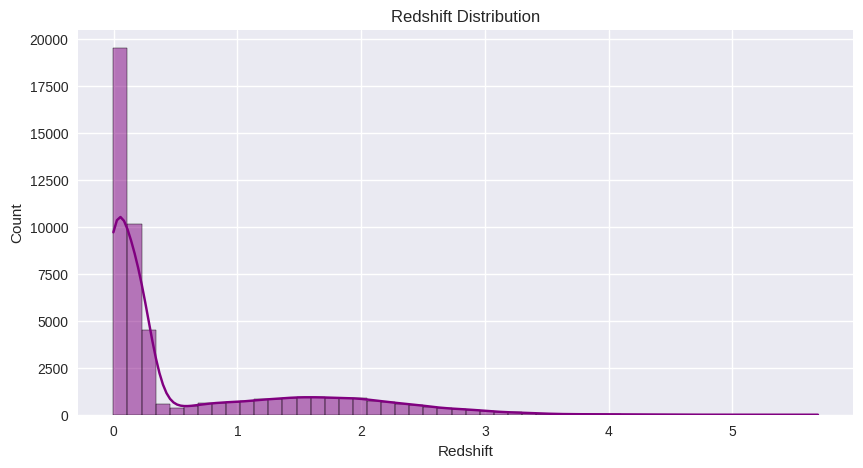

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df['redshift'], bins=50, kde=True, color='purple')
plt.title("Redshift Distribution")
plt.xlabel("Redshift")
plt.ylabel("Count")
plt.show()

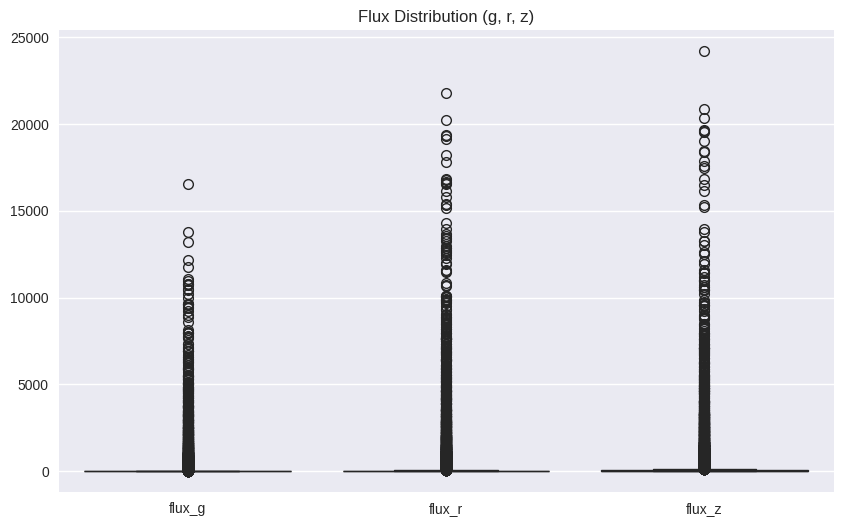

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['flux_g','flux_r','flux_z']], palette=['red','green','blue'])
plt.title("Flux Distribution (g, r, z)")
plt.show()

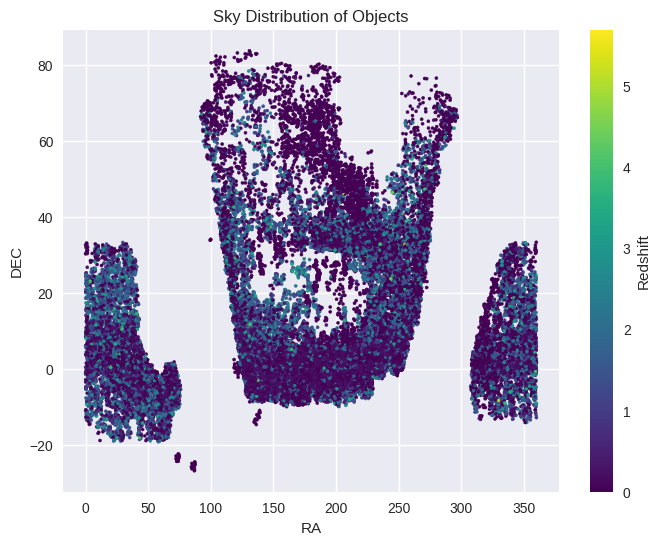

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(df['ra'], df['dec'], c=df['redshift'], cmap='viridis', s=5)
plt.colorbar(label='Redshift')
plt.xlabel("RA")
plt.ylabel("DEC")
plt.title("Sky Distribution of Objects")
plt.show()

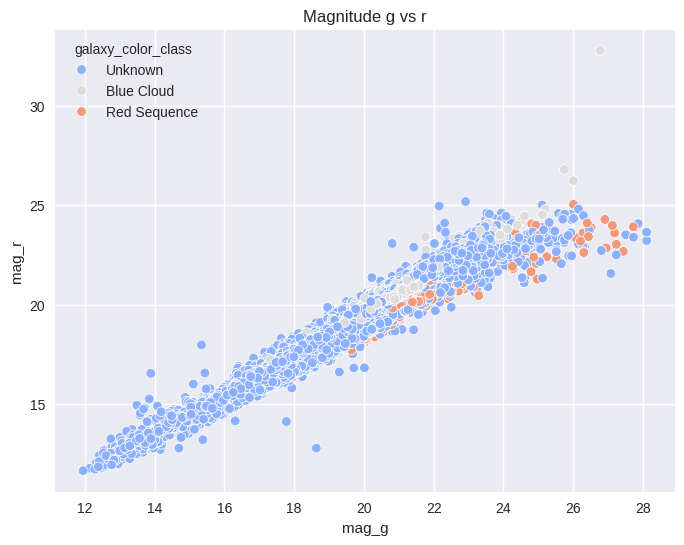

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['mag_g'], 
    y=df['mag_r'], 
    hue=df['galaxy_color_class'],
    palette='coolwarm'
)
plt.title("Magnitude g vs r")
plt.show()

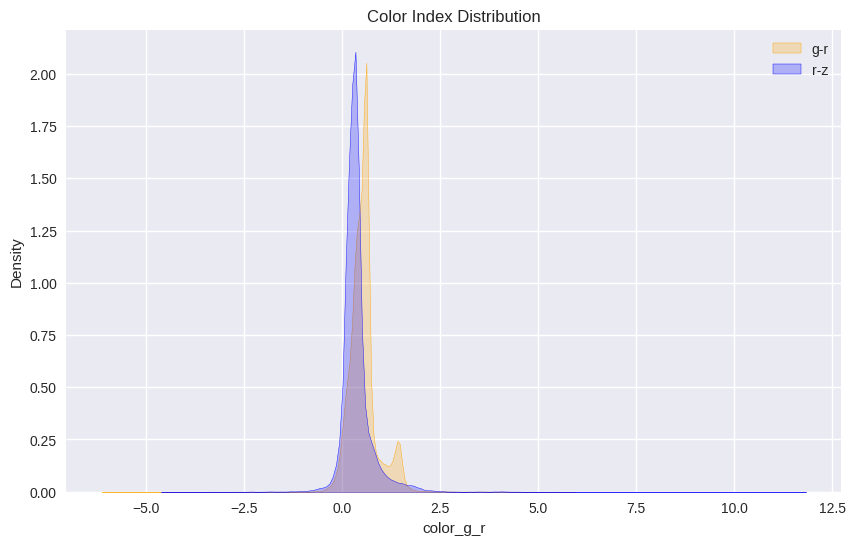

In [19]:
plt.figure(figsize=(10,6))
sns.kdeplot(df['color_g_r'], fill=True, color='orange', label='g-r')
sns.kdeplot(df['color_r_z'], fill=True, color='blue', label='r-z')
plt.legend()
plt.title("Color Index Distribution")
plt.show()

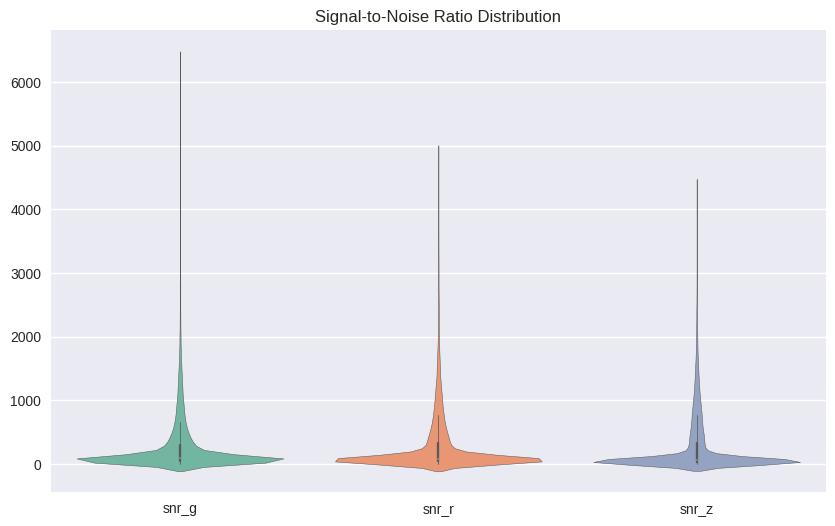

In [20]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df[['snr_g','snr_r','snr_z']], palette='Set2')
plt.title("Signal-to-Noise Ratio Distribution")
plt.show()

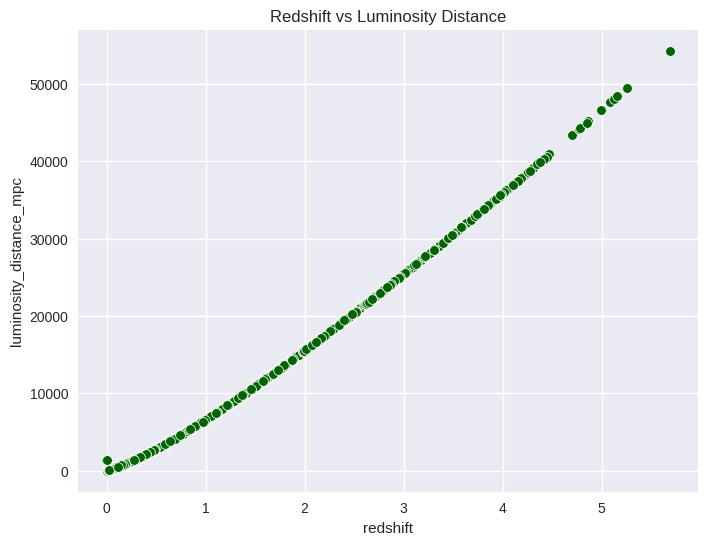

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['redshift'], 
    y=df['luminosity_distance_mpc'], 
    color='darkgreen'
)
plt.title("Redshift vs Luminosity Distance")
plt.show()

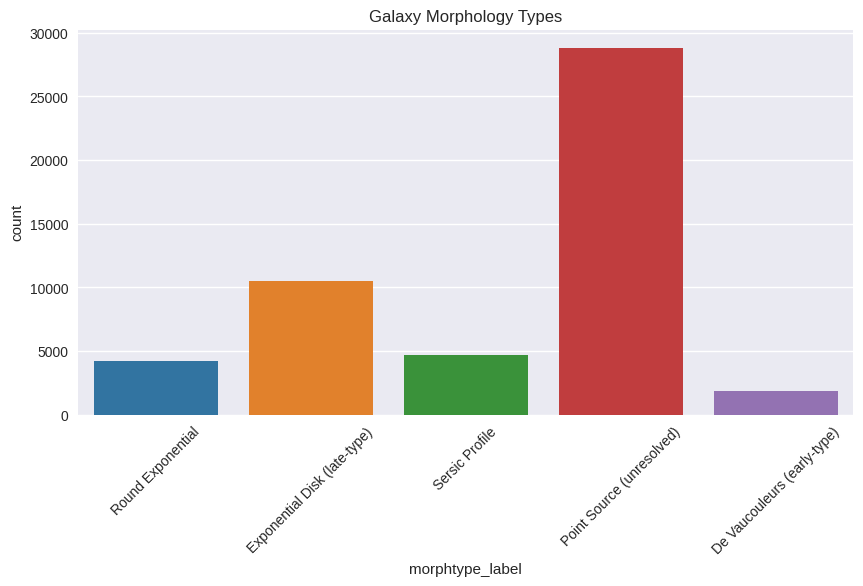

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df, 
    x='morphtype_label', 
    palette='tab10'
)
plt.xticks(rotation=45)
plt.title("Galaxy Morphology Types")
plt.show()

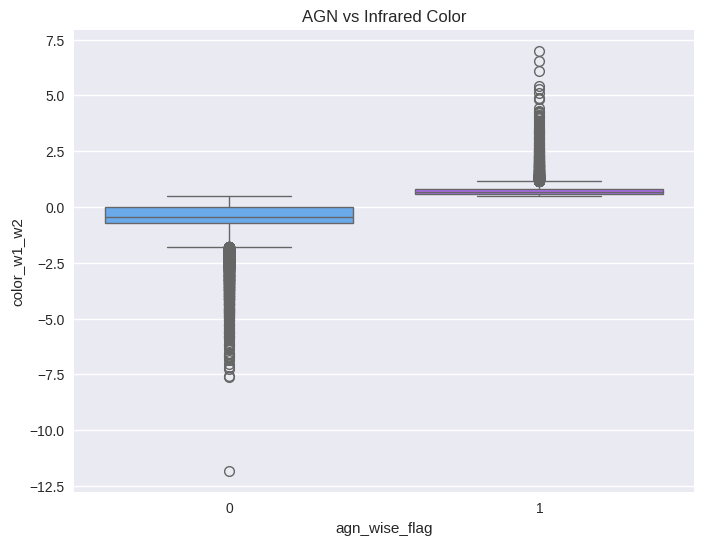

In [23]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x='agn_wise_flag', 
    y='color_w1_w2', 
    data=df,
    palette='cool'
)
plt.title("AGN vs Infrared Color")
plt.show()

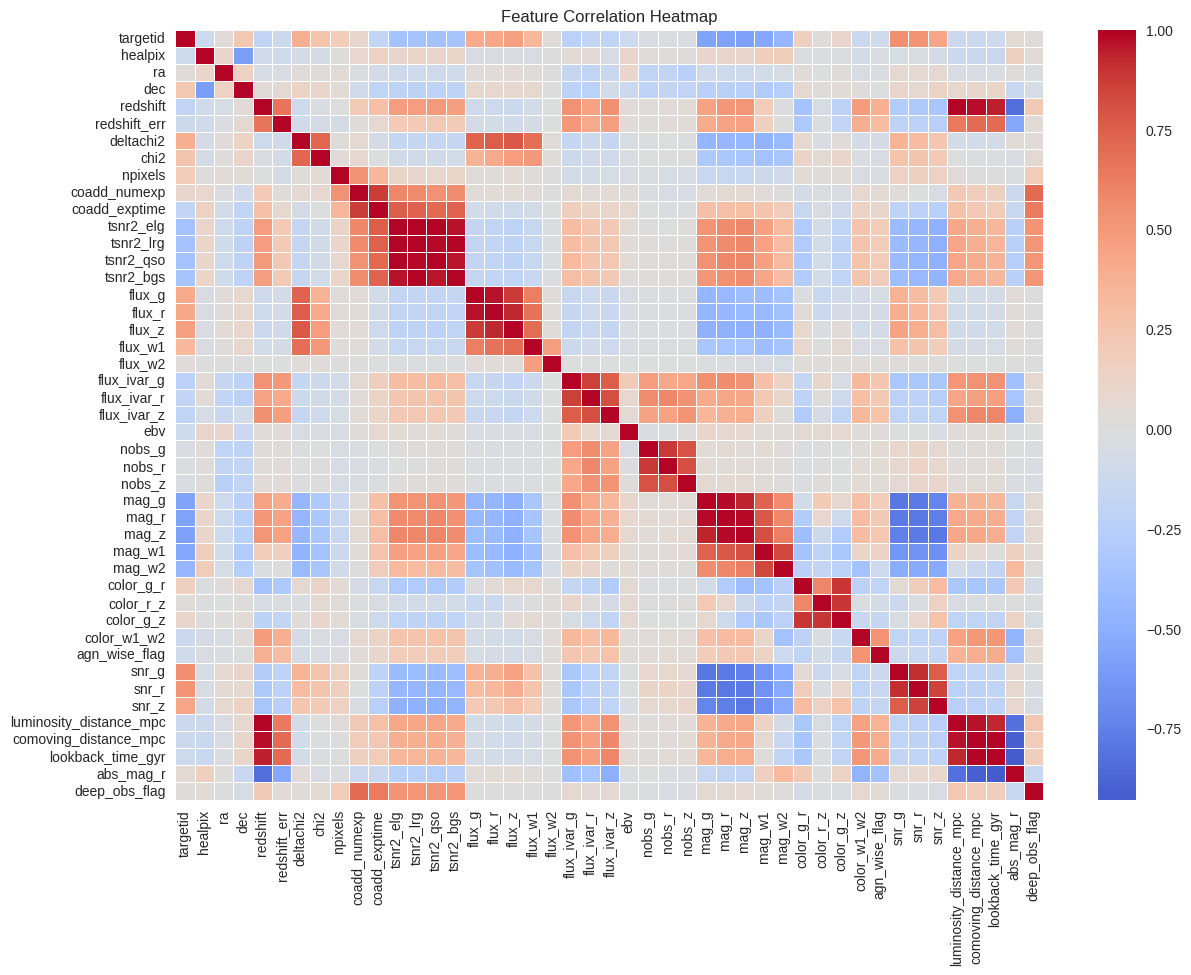

In [24]:
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

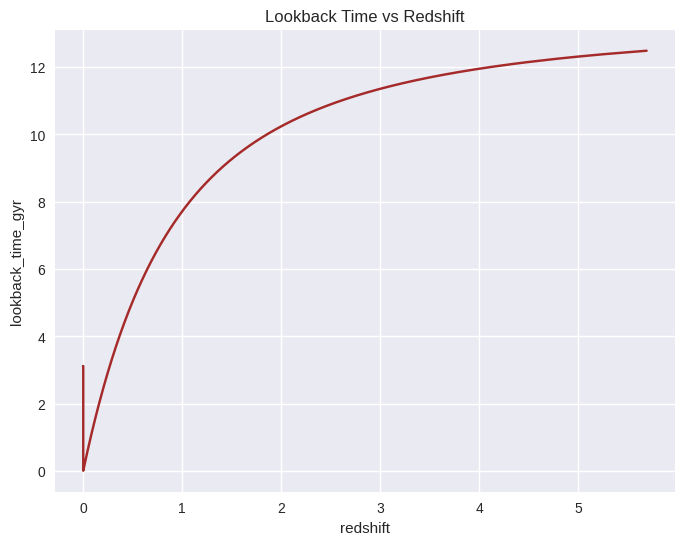

In [25]:
plt.figure(figsize=(8,6))
sns.lineplot(
    x=df['redshift'], 
    y=df['lookback_time_gyr'], 
    color='brown'
)
plt.title("Lookback Time vs Redshift")
plt.show()

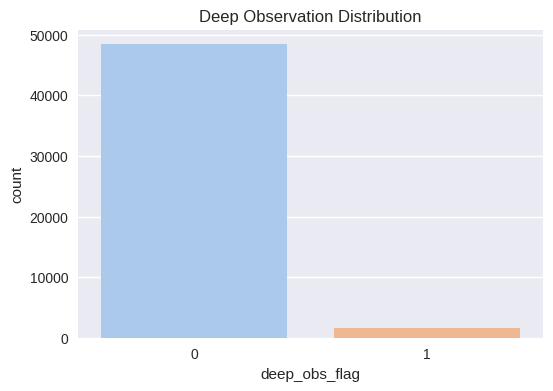

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='deep_obs_flag', 
    data=df,
    palette='pastel'
)
plt.title("Deep Observation Distribution")
plt.show()

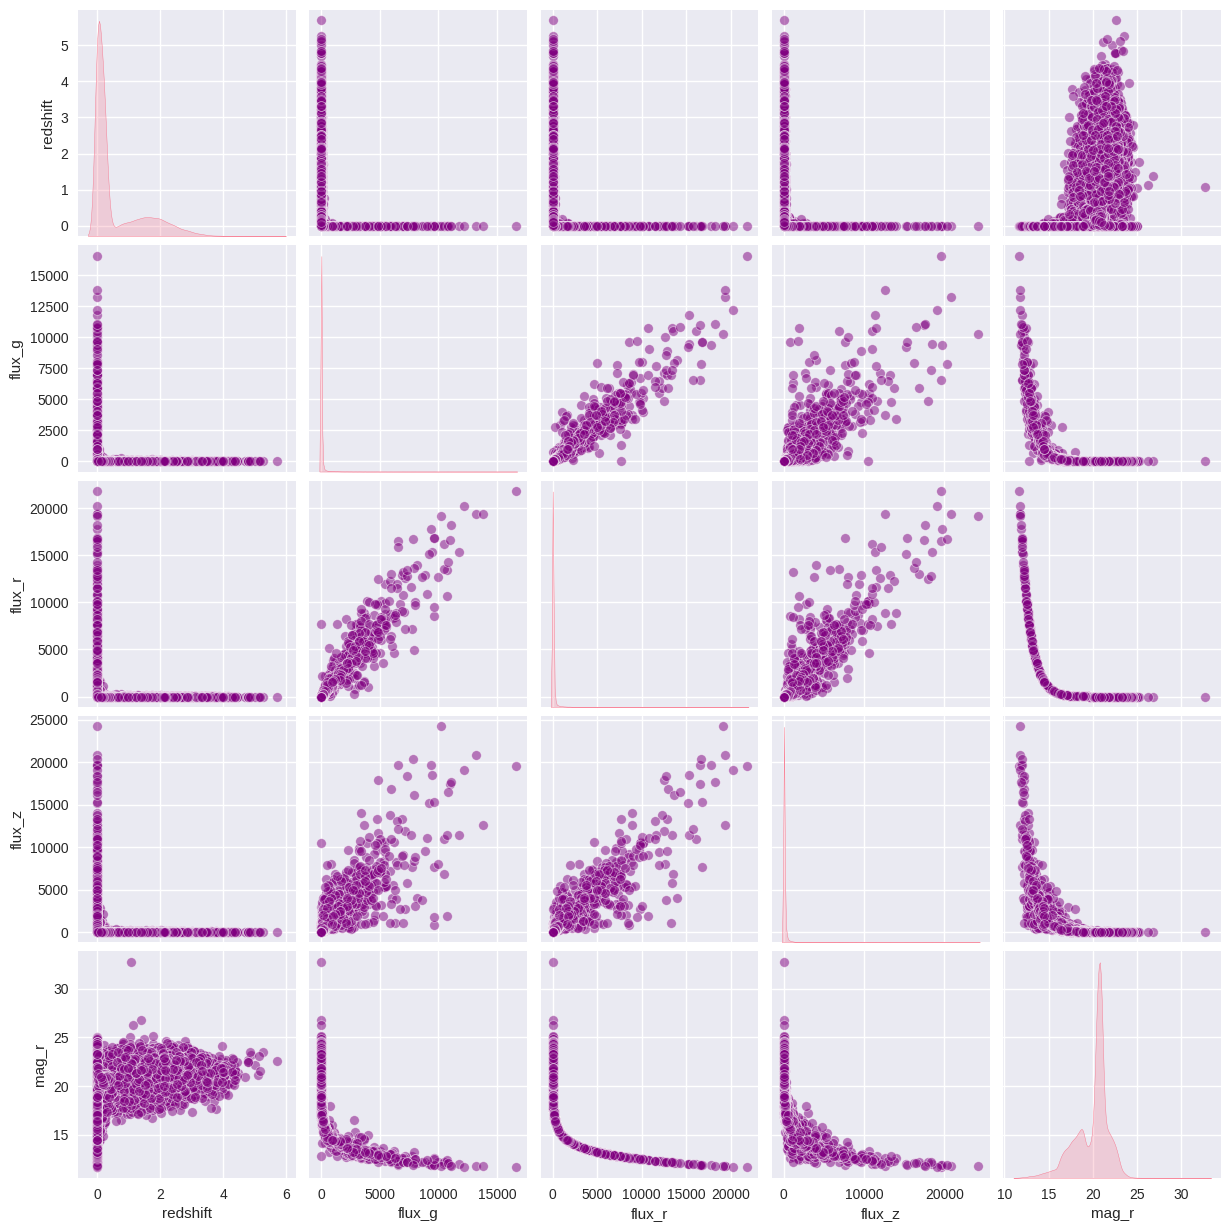

In [27]:
sns.pairplot(
    df[['redshift','flux_g','flux_r','flux_z','mag_r']],
    diag_kind='kde',
    plot_kws={'alpha':0.5, 'color':'purple'}
)
plt.show()

## Feature engineering

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [29]:
print(df.shape)
df.head()

(50000, 51)


,targetid,healpix,ra,dec,redshift,redshift_err,spectype,subtype,deltachi2,chi2,...,snr_r,snr_z,luminosity_distance_mpc,comoving_distance_mpc,lookback_time_gyr,abs_mag_r,redshift_confidence,morphtype_label,galaxy_color_class,deep_obs_flag
0,39628365690307709,741,33.037640,24.844902,1.747032,0.001586,QSO,HIZ,28.401550,7534.991513,...,7.729358,9.117406,13163.869822,4792.033371,9.799481,-22.286156,Moderate,Round Exponential,Unknown,0
1,2714944399212545,17996,16.571421,-1.504480,0.209861,0.000009,GALAXY,Unknown,572.310340,7875.553116,...,137.393962,73.856041,1034.289646,854.883064,2.535272,-19.524550,High,Exponential Disk (late-type),Blue Cloud,0
2,2349936800694272,18006,20.330022,-0.340878,0.766918,0.000142,GALAXY,Unknown,197.099793,7808.884794,...,106.028605,79.282391,4764.048821,2696.247689,6.660354,-22.827631,High,Sersic Profile,Red Sequence,0
3,2715032676728834,31429,238.474281,2.067749,0.199573,0.000006,GALAXY,Unknown,1317.058164,7679.890371,...,80.824023,49.891636,977.733498,815.067700,2.427478,-19.148888,Very High,Exponential Disk (late-type),Red Sequence,0
4,2305843019036772569,9369,243.782457,29.614561,-0.000806,0.000009,STAR,K,1172.646961,7677.044633,...,605.532808,462.925362,1367.251681,1077.813388,3.122206,-20.060933,Very High,Point Source (unresolved),Unknown,0


In [30]:
# Avoid leakage: use ONLY this column to define target
threshold = df['redshift'].median()

df['target'] = (df['redshift'] > threshold).astype(int)

print(df['target'].value_counts())

target
1    25000
0    25000
Name: count, dtype: int64


In [31]:
leakage_cols = [
    'redshift', 
    'redshift_err', 
    'redshift_confidence'
]

df = df.drop(columns=leakage_cols)

In [32]:
X = df.drop(columns=['target'])
y = df['target']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(include=np.number).columns

In [35]:
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    
    # Handle unseen labels in test
    X_test[col] = X_test[col].astype(str).map(
        lambda s: '<UNK>' if s not in le.classes_ else s
    )
    
    le.classes_ = np.append(le.classes_, '<UNK>')
    X_test[col] = le.transform(X_test[col])
    
    encoders[col] = le

In [36]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}


In [38]:
for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = (acc, roc_auc)
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("ROC-AUC:", roc_auc)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Logistic Regression
Accuracy: 0.9913
ROC-AUC: 0.99943008
Confusion Matrix:
[[4952   48]
 [  39 4961]]

Random Forest
Accuracy: 1.0
ROC-AUC: 0.9999999999999999
Confusion Matrix:
[[5000    0]
 [   0 5000]]

Gradient Boosting
Accuracy: 0.9999
ROC-AUC: 0.9999999199999999
Confusion Matrix:
[[5000    0]
 [   1 4999]]


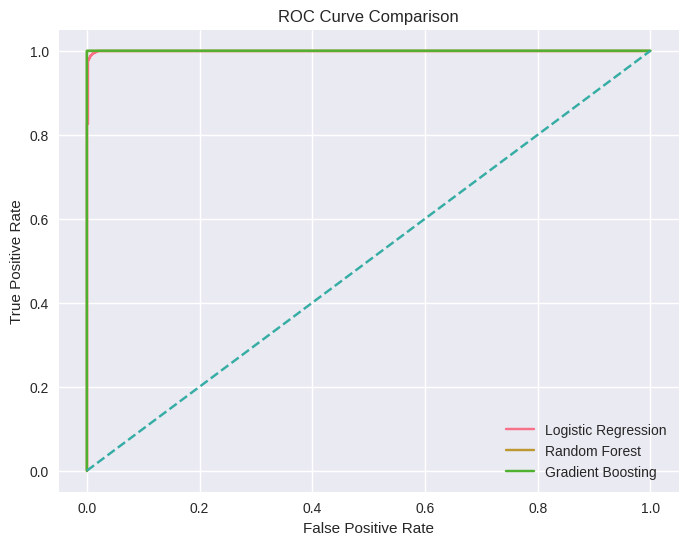

In [39]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=name)

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [40]:
results_df = pd.DataFrame(results, index=['Accuracy','ROC-AUC']).T

print("\nModel Comparison:")
print(results_df)


Model Comparison:
                     Accuracy  ROC-AUC
Logistic Regression    0.9913  0.99943
Random Forest          1.0000  1.00000
Gradient Boosting      0.9999  1.00000


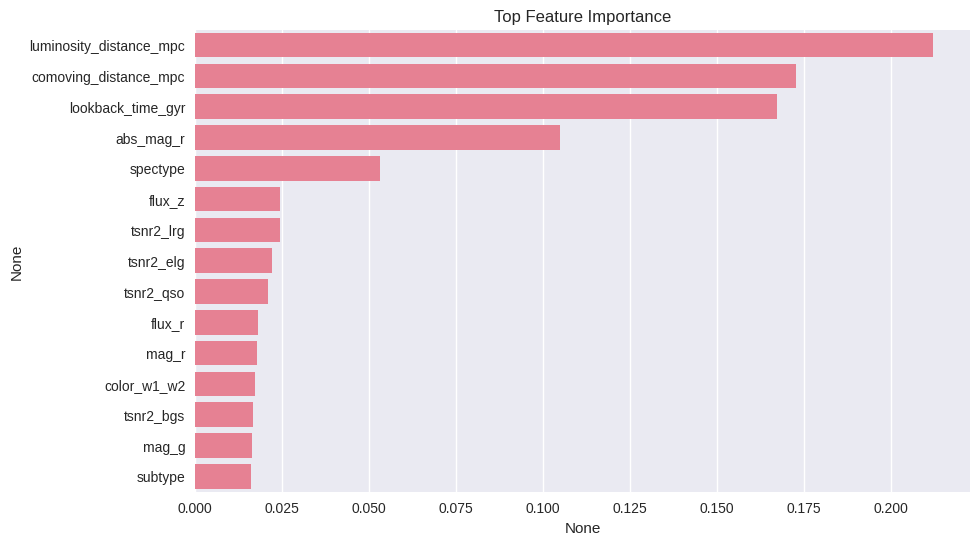

In [41]:
rf_model = models["Random Forest"]

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=importances.index)
plt.title("Top Feature Importance")
plt.show()

## Thank you..pls upvote!!!!!!!!!